# MNIST-Style Digit PCA Across Scripts

This version uses only verified handwritten MNIST-style digit datasets. Tamil and Thai are dropped because I could not verify clean MNIST-equivalent digit datasets locally.


In [1]:
from itertools import combinations
from pathlib import Path
from urllib.request import urlretrieve

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from tfrecord.reader import tfrecord_loader

N_PER_DIGIT = 250
IMG_SIZE = 28
LANGUAGES = ["English", "Mandarin Chinese", "Hindi", "Arabic", "Bengali", "Urdu/Persian", "Telugu"]

DATASET_SOURCES = {
    "English": "OpenML MNIST 784",
    "Mandarin Chinese": "Kaggle gpreda/chinese-mnist",
    "Hindi": "Kaggle anurags397/hindi-mnist-data",
    "Arabic": "Kaggle mloey1/ahdd1",
    "Bengali": "Kaggle wchowdhu/bengali-digits",
    "Urdu/Persian": "Kaggle teerathkumar142/urdumnist",
    "Telugu": "CMATERdb Telugu numerals",
}

data = {}
embeddings = {}
shared_embeddings = {}
rng = np.random.default_rng(0)


def normalize_rows(X):
    X = X.astype("float32")
    if X.max() > 1:
        X /= 255
    X[X.mean(axis=1) > 0.5] = 1 - X[X.mean(axis=1) > 0.5]
    maxes = X.max(axis=1, keepdims=True)
    return np.divide(X, maxes, out=np.zeros_like(X), where=maxes > 0)


def balance(X, y, n=N_PER_DIGIT):
    keep = np.concatenate([rng.choice(np.flatnonzero(y == digit), n, replace=False) for digit in range(10)])
    return normalize_rows(X[keep]), y[keep].astype(int)


def image_to_row(path_or_image):
    image = path_or_image if isinstance(path_or_image, Image.Image) else Image.open(path_or_image)
    arr = np.asarray(image.convert("L").resize((IMG_SIZE, IMG_SIZE)), dtype="float32").reshape(1, -1)
    return normalize_rows(arr)[0]


def images_to_rows(images):
    rows = []
    for image in images:
        if image.ndim == 3:
            image = image.mean(axis=2)
        rows.append(image_to_row(Image.fromarray(image.astype("uint8"))))
    return np.array(rows, dtype="float32")


def load_image_folders(base, pattern="*"):
    X, y = [], []
    for digit in range(10):
        paths = sorted((base / str(digit)).glob(pattern))[:N_PER_DIGIT]
        X.extend(image_to_row(path) for path in paths)
        y.extend([digit] * len(paths))
    return np.array(X, dtype="float32"), np.array(y)


def plot_embedding(Z, y, title, ax=None, s=5, colorbar=True):
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(Z[:, 0], Z[:, 1], c=y, cmap="tab10", vmin=0, vmax=9, s=s, alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    if colorbar:
        ax.figure.colorbar(scatter, ax=ax, ticks=range(10), label="Digit")


def plot_language(language):
    X, y = data[language]
    Z = PCA(n_components=2, random_state=0).fit_transform(X)
    embeddings[language] = Z
    plot_embedding(Z, y, language)
    plt.show()


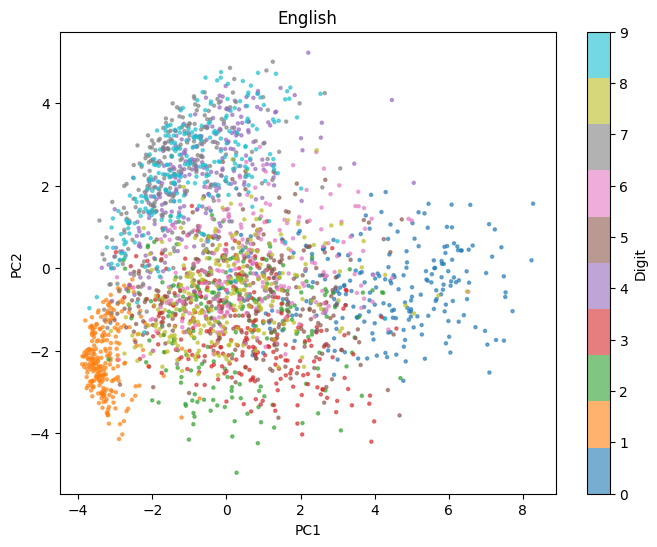

In [2]:
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X, y = balance(mnist.data, mnist.target.astype(int))
data["English"] = (X, y)
plot_language("English")


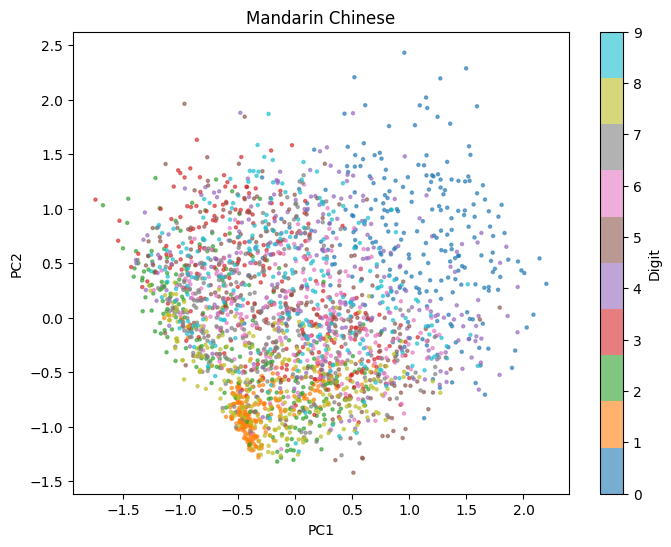

In [3]:
path = Path(kagglehub.dataset_download("gpreda/chinese-mnist"))
rows = np.loadtxt(path / "chinese_mnist.csv", delimiter=",", skiprows=1, usecols=(0, 1, 2, 3), dtype=int)
value_by_key = {s * 1_000_000 + sample * 1_000 + code: value for s, sample, code, value in rows}

X, y = [], []
for record in tfrecord_loader(str(path / "chinese_mnist.tfrecords"), None, None):
    value = value_by_key[int(record["label"][0])]
    if value <= 9:
        image = np.frombuffer(record["image_raw"], dtype=np.uint8).reshape(64, 64)
        X.append(image_to_row(Image.fromarray(image)))
        y.append(value)

X, y = balance(np.array(X), np.array(y))
data["Mandarin Chinese"] = (X, y)
plot_language("Mandarin Chinese")


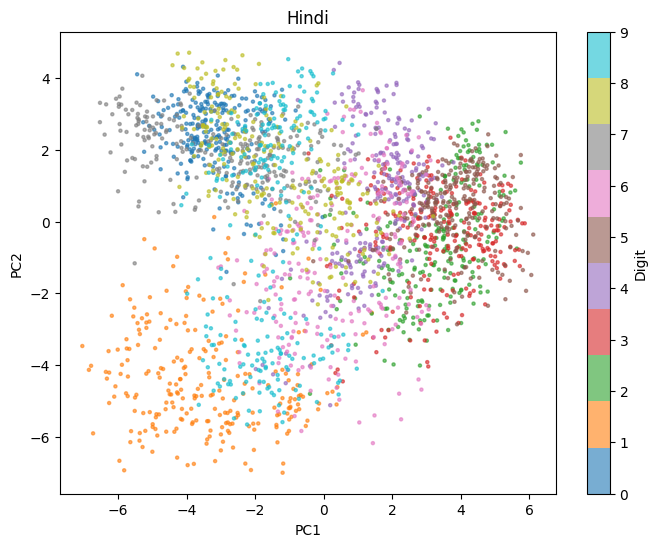

In [4]:
path = Path(kagglehub.dataset_download("anurags397/hindi-mnist-data"))
base = path / "DevanagariHandwrittenDigitDataset" / "DevanagariHandwrittenDigitDataset" / "Train"

X, y = [], []
for digit in range(10):
    paths = sorted((base / f"digit_{digit}").glob("*.png"))[:N_PER_DIGIT]
    X.extend(image_to_row(path) for path in paths)
    y.extend([digit] * len(paths))

data["Hindi"] = (np.array(X, dtype="float32"), np.array(y))
plot_language("Hindi")


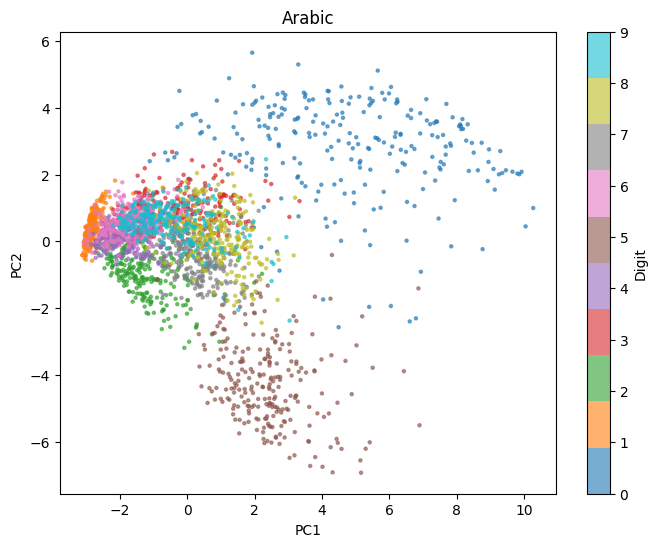

In [5]:
path = Path(kagglehub.dataset_download("mloey1/ahdd1")) / "Arabic Handwritten Digits Dataset CSV"
X = np.loadtxt(path / "csvTrainImages 60k x 784.csv", delimiter=",", max_rows=N_PER_DIGIT * 10, dtype="float32")
y = np.loadtxt(path / "csvTrainLabel 60k x 1.csv", delimiter=",", max_rows=N_PER_DIGIT * 10, dtype=int).reshape(-1)
X, y = balance(X, y)

data["Arabic"] = (X, y)
plot_language("Arabic")


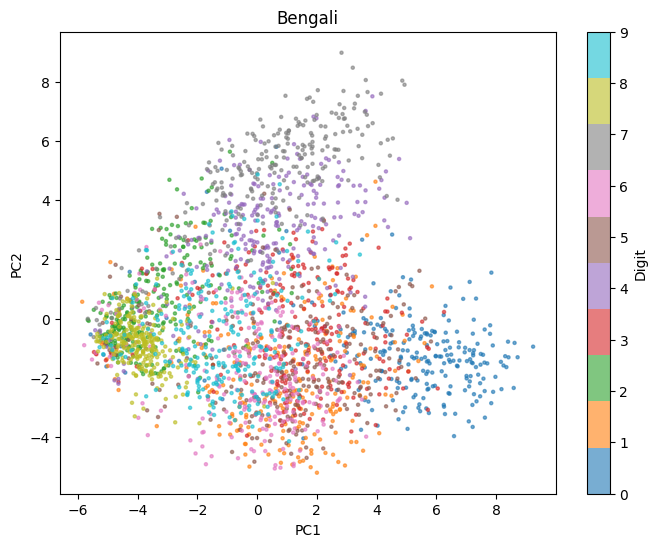

In [6]:
path = Path(kagglehub.dataset_download("wchowdhu/bengali-digits")) / "bengali_digits"
X, y = load_image_folders(path, "*.jpg")
data["Bengali"] = (X, y)
plot_language("Bengali")


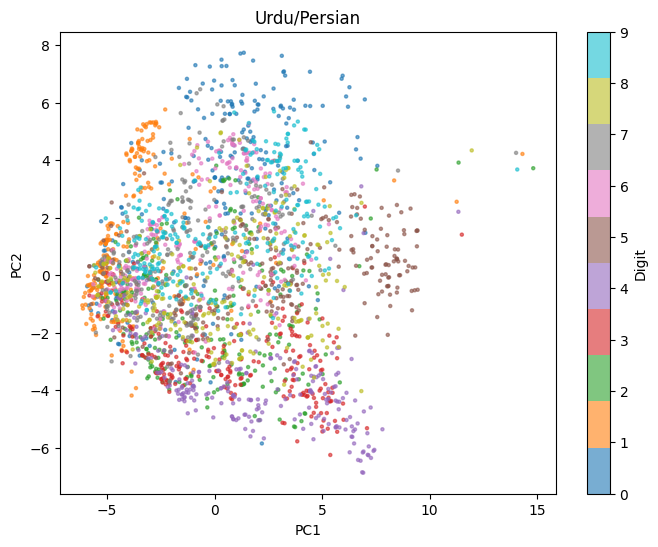

In [7]:
path = Path(kagglehub.dataset_download("teerathkumar142/urdumnist")) / "UrduDataset" / "x_train" / "x_train"
X, y = load_image_folders(path, "*.jpg")
data["Urdu/Persian"] = (X, y)
plot_language("Urdu/Persian")


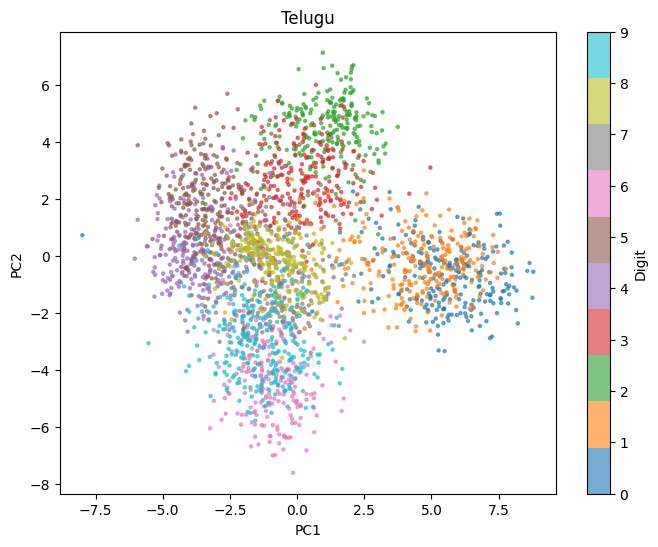

In [8]:
path = Path("data_sources/cmaterdb_telugu/telugu-training-images.npz")
path.parent.mkdir(parents=True, exist_ok=True)
if not path.exists():
    urlretrieve(
        "https://raw.githubusercontent.com/prabhuomkar/CMATERdb/master/datasets/telugu-numerals/training-images.npz",
        path,
    )

archive = np.load(path)
X = images_to_rows(archive["images"])
y = archive["labels"].astype(int)
X, y = balance(X, y)

data["Telugu"] = (X, y)
plot_language("Telugu")


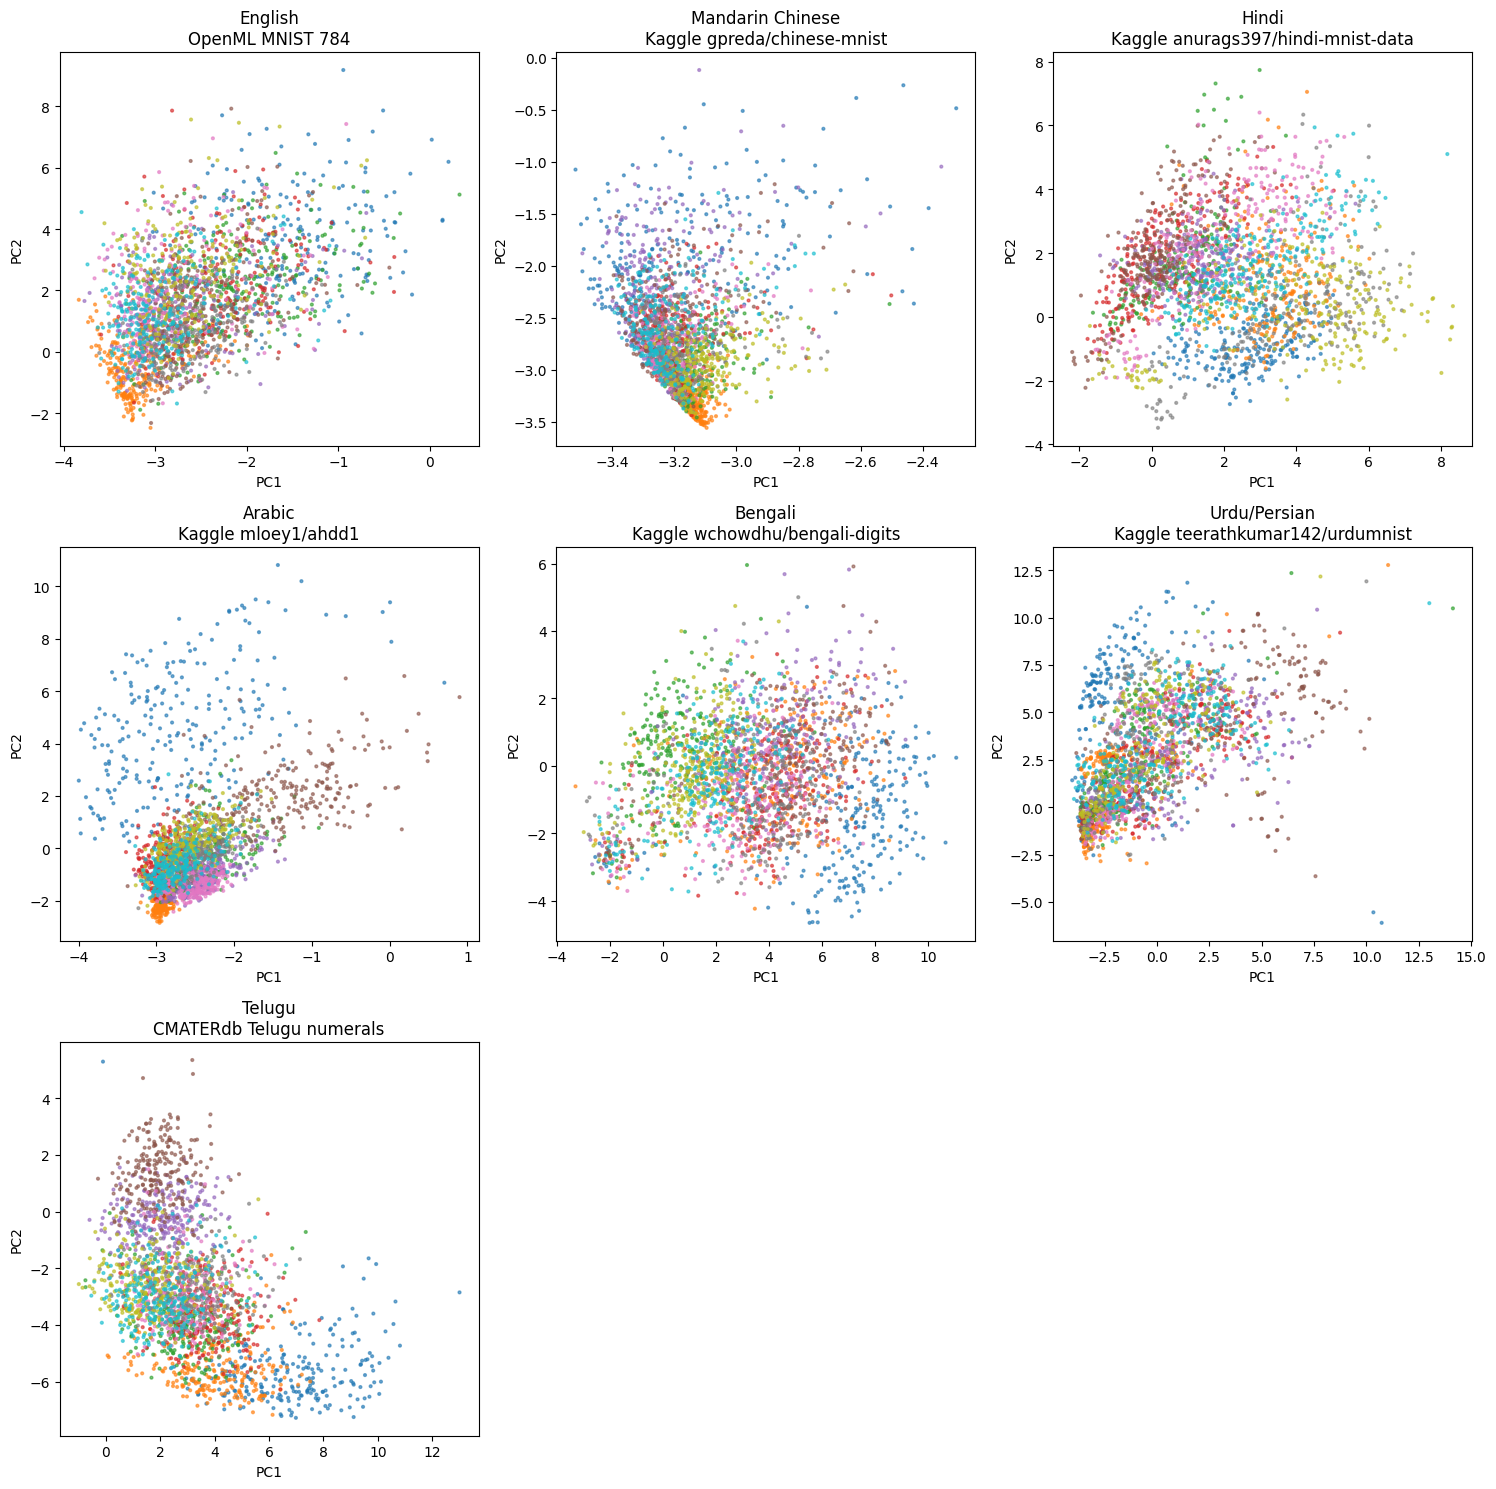

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.ravel()

X_all = np.vstack([data[language][0] for language in LANGUAGES])
Z_all = PCA(n_components=2, random_state=0).fit_transform(X_all)

start = 0
for language in LANGUAGES:
    n = len(data[language][0])
    shared_embeddings[language] = Z_all[start:start + n]
    start += n

for ax, language in zip(axes, LANGUAGES):
    _, y = data[language]
    plot_embedding(shared_embeddings[language], y, f"{language}\n{DATASET_SOURCES[language]}", ax=ax, s=4, colorbar=False)

for ax in axes[len(LANGUAGES):]:
    ax.axis("off")

fig.tight_layout()
plt.show()


In [10]:
rows = []
for language in LANGUAGES:
    Z = shared_embeddings[language]
    _, y = data[language]
    centroids = np.array([Z[y == digit].mean(axis=0) for digit in range(10)])
    distances = [np.linalg.norm(centroids[a] - centroids[b]) for a, b in combinations(range(10), 2)]
    rows.append((language, np.mean(distances), np.min(distances), np.max(distances)))

rows = sorted(rows, key=lambda row: row[1], reverse=True)
print(f"{'Language':<18} {'Mean':>10} {'Min':>10} {'Max':>10}")
for language, mean_distance, min_distance, max_distance in rows:
    print(f"{language:<18} {mean_distance:10.3f} {min_distance:10.3f} {max_distance:10.3f}")


Language                 Mean        Min        Max
Telugu                  3.055      0.336      8.324
Bengali                 2.311      0.416      6.394
Urdu/Persian            2.171      0.250      5.997
Hindi                   2.143      0.296      4.238
Arabic                  2.071      0.339      6.343
English                 1.365      0.258      4.227
Mandarin Chinese        0.466      0.027      1.417


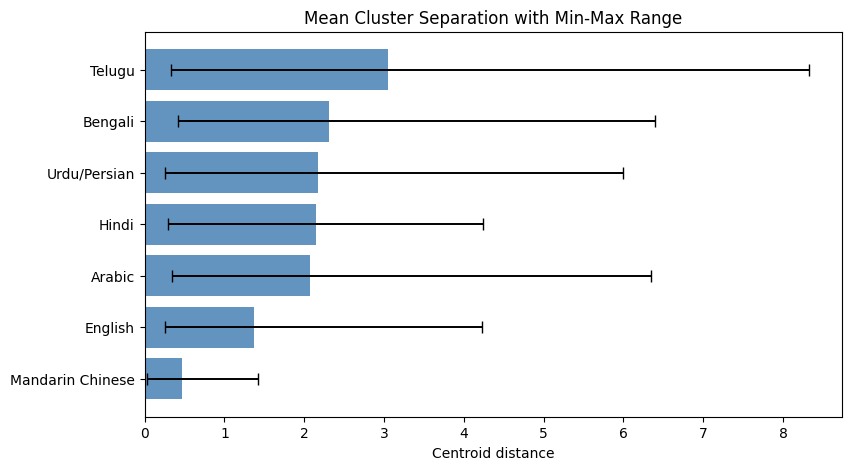

In [11]:
languages = [row[0] for row in rows]
means = np.array([row[1] for row in rows])
mins = np.array([row[2] for row in rows])
maxes = np.array([row[3] for row in rows])

fig, ax = plt.subplots(figsize=(9, 5))
y_pos = np.arange(len(languages))
ax.barh(y_pos, means, color="steelblue", alpha=0.85)
ax.errorbar(means, y_pos, xerr=[means - mins, maxes - means], fmt="none", ecolor="black", capsize=4, lw=1.4)
ax.set_yticks(y_pos, labels=languages)
ax.invert_yaxis()
ax.set_xlabel("Centroid distance")
ax.set_title("Mean Cluster Separation with Min-Max Range")
plt.show()
